# Лабораторная работа №1
## Необходимые и достаточные условия существования условного экстремума

### Вариант 1.2

**Задача:**

$$f(x) = (x_1^3 - x_2)^2 + x_2^2 \to extr$$

$$g_1(x) = x_1^2 + x_2^2 - 1 \leq 0$$

$$g_2(x) = -x_1 \leq 0$$

**Множество допустимых решений:**

$$X = \{x \in \mathbb{R}^2 \mid x_1^2 + x_2^2 \leq 1,\ x_1 \geq 0\}$$

Это правая половина единичного круга.


In [4]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LogNorm
from IPython.display import display, Math
sp.init_printing(use_latex='mathjax')

# Символьные переменные
x1, x2 = sp.symbols('x1 x2', real=True)
l1, l2  = sp.symbols('lambda1 lambda2', real=True)

print("Библиотеки загружены ✓")


Библиотеки загружены ✓


## 1. Постановка задачи — символьное определение функций

In [5]:
# Целевая функция
f = (x1**3 - x2)**2 + x2**2

# Ограничения (в форме g(x) <= 0)
g1 = x1**2 + x2**2 - 1
g2 = -x1

print("Целевая функция:")
display(Math(r'f(x) = ' + sp.latex(f)))
print()
print("Ограничения:")
display(Math(r'g_1(x) = ' + sp.latex(g1) + r' \leq 0'))
display(Math(r'g_2(x) = ' + sp.latex(g2) + r' \leq 0'))


Целевая функция:


<IPython.core.display.Math object>


Ограничения:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 2. Функция Лагранжа и условия KKT

Классическая функция Лагранжа:

$$L(x, \lambda) = f(x) + \lambda_1 g_1(x) + \lambda_2 g_2(x)$$


In [6]:
# Функция Лагранжа
L = f + l1*g1 + l2*g2

print("Функция Лагранжа:")
display(Math(r'L(x,\lambda) = ' + sp.latex(sp.expand(L))))


Функция Лагранжа:


<IPython.core.display.Math object>

## 3. Необходимые условия экстремума первого порядка (KKT)

**А) Условие стационарности:**
$$\frac{\partial L}{\partial x_i} = 0, \quad i = 1, 2$$

**Б) Условие допустимости:**
$$g_j(x^e) \leq 0, \quad j = 1, 2$$

**В) Условие неотрицательности (для минимума):**
$$\lambda_j \geq 0, \quad j = 1, 2$$

**Г) Условие дополняющей нежёсткости:**
$$\lambda_j \cdot g_j(x^e) = 0, \quad j = 1, 2$$


In [7]:
# Градиент функции Лагранжа по x
dL_x1 = sp.diff(L, x1)
dL_x2 = sp.diff(L, x2)

print("Условия стационарности ∂L/∂x1 = 0:")
display(Math(sp.latex(dL_x1) + r' = 0'))
print()
print("Условия стационарности ∂L/∂x2 = 0:")
display(Math(sp.latex(dL_x2) + r' = 0'))


Условия стационарности ∂L/∂x1 = 0:


<IPython.core.display.Math object>


Условия стационарности ∂L/∂x2 = 0:


<IPython.core.display.Math object>

## 4. Анализ случаев активности ограничений

Из условия дополняющей нежёсткости $\lambda_j g_j(x^e) = 0$:
- если $\lambda_j > 0$ — ограничение **активно**: $g_j(x^e) = 0$
- если $g_j(x^e) < 0$ — ограничение **пассивно**: $\lambda_j = 0$

Возможные случаи:

| Случай | $g_1$ | $g_2$ | $\lambda_1$ | $\lambda_2$ |
|--------|--------|--------|--------------|--------------|
| 1      | пассивно | пассивно | 0 | 0 |
| 2      | активно  | пассивно | свободна | 0 |
| 3      | пассивно | активно  | 0 | свободна |
| 4      | активно  | активно  | свободна | свободна |


### Случай 1: оба ограничения пассивны ($\lambda_1=0$, $\lambda_2=0$)

In [8]:
# Случай 1: lambda1=0, lambda2=0 => grad f = 0
sys1 = [dL_x1.subs([(l1,0),(l2,0)]),
        dL_x2.subs([(l1,0),(l2,0)])]

print("Система уравнений:")
for eq in sys1:
    display(Math(sp.latex(eq) + r' = 0'))

sol1 = sp.solve(sys1, [x1, x2], dict=True)
print("\nРешения:")
for s in sol1:
    xv = (s[x1], s[x2])
    fv = f.subs(s)
    g1v = g1.subs(s)
    g2v = g2.subs(s)
    feasible = g1v <= 0 and g2v <= 0
    print(f"  x = {xv},  f = {fv},  g1 = {g1v},  g2 = {g2v},  допустима: {feasible}")


Система уравнений:


<IPython.core.display.Math object>

<IPython.core.display.Math object>


Решения:
  x = (0, 0),  f = 0,  g1 = -1,  g2 = 0,  допустима: True


### Случай 2: активно $g_1$, пассивно $g_2$ ($g_1=0$, $\lambda_2=0$)

In [9]:
# Случай 2: g1=0, lambda2=0
sys2 = [dL_x1.subs(l2, 0),
        dL_x2.subs(l2, 0),
        g1]  # g1 = 0

print("Система уравнений:")
for eq in sys2:
    display(Math(sp.latex(eq) + r' = 0'))

sol2 = sp.solve(sys2, [x1, x2, l1], dict=True)
print(f"\nНайдено решений: {len(sol2)}")
for s in sol2:
    xv = (s[x1], s[x2])
    l1v = s[l1]
    fv = f.subs(s)
    g2v = g2.subs(s)
    feasible_dom = g2v <= 0
    # для минимума нужно lambda1 >= 0
    kkt_ok = l1v >= 0
    print(f"  x = ({float(s[x1]):.6f}, {float(s[x2]):.6f})")
    print(f"  λ₁ = {l1v} ≈ {float(l1v):.6f}")
    print(f"  f  = {float(fv):.6f},  g2 = {float(g2v):.6f}")
    print(f"  Допустима (g2≤0): {feasible_dom},  KKT (λ1≥0): {bool(kkt_ok)}")
    print()


Система уравнений:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>


Найдено решений: 2
  x = (0.000000, -1.000000)
  λ₁ = -2 ≈ -2.000000
  f  = 2.000000,  g2 = 0.000000
  Допустима (g2≤0): True,  KKT (λ1≥0): False

  x = (0.000000, 1.000000)
  λ₁ = -2 ≈ -2.000000
  f  = 2.000000,  g2 = 0.000000
  Допустима (g2≤0): True,  KKT (λ1≥0): False



### Случай 3: пассивно $g_1$, активно $g_2$ ($\lambda_1=0$, $g_2=0 \Rightarrow x_1=0$)

In [10]:
# Случай 3: lambda1=0, g2=0 => x1=0
sys3 = [dL_x1.subs([(l1,0),(x1,0)]),
        dL_x2.subs([(l1,0),(x1,0)])]

print("Подставляем x1=0, lambda1=0:")
print("Система уравнений:")
for eq in sys3:
    display(Math(sp.latex(eq) + r' = 0'))

sol3_x2 = sp.solve(sys3[1], x2)  # уравнение по x2
print(f"\nРешения по x2: {sol3_x2}")

for x2v in sol3_x2:
    s = {x1: 0, x2: x2v}
    # lambda2 из первого уравнения
    eq_l2 = dL_x1.subs([(l1,0),(x1,0),(x2,x2v)])
    l2v = sp.solve(eq_l2, l2)
    fv = f.subs(s)
    g1v = g1.subs(s)
    print(f"  x = (0, {x2v}),  f = {fv},  g1 = {g1v}")
    print(f"  λ₂ = {l2v}")
    print(f"  Допустима (g1≤0): {g1v <= 0}")
    print()


Подставляем x1=0, lambda1=0:
Система уравнений:


<IPython.core.display.Math object>

<IPython.core.display.Math object>


Решения по x2: [0]
  x = (0, 0),  f = 0,  g1 = -1
  λ₂ = [0]
  Допустима (g1≤0): True



### Случай 4: оба ограничения активны ($g_1=0$, $g_2=0 \Rightarrow x_1=0, x_1^2+x_2^2=1$)

In [11]:
# g2=0 => x1=0; g1=0 => x2^2=1 => x2=±1
# Проверяем обе точки
case4_points = [(0, 1), (0, -1)]

print("Из g2=0: x1=0, из g1=0: x2²=1 => x2=±1\n")

for xv in case4_points:
    s = {x1: xv[0], x2: xv[1]}
    # Находим λ1, λ2 из условий стационарности
    eq1 = dL_x1.subs(s)
    eq2 = dL_x2.subs(s)
    lambdas = sp.solve([eq1, eq2], [l1, l2], dict=True)
    fv = float(f.subs(s))
    print(f"  Точка x = {xv},  f = {fv}")
    if lambdas:
        for ls in lambdas:
            print(f"  λ₁ = {ls.get(l1,'?')},  λ₂ = {ls.get(l2,'?')}")
            for lk, lv in ls.items():
                try:
                    print(f"    {lk} = {float(lv):.4f}", end='  ')
                except:
                    pass
            print()
    else:
        print("  Нет решения для множителей Лагранжа")
    print()


Из g2=0: x1=0, из g1=0: x2²=1 => x2=±1

  Точка x = (0, 1),  f = 2.0
  λ₁ = -2,  λ₂ = 0
    lambda1 = -2.0000      lambda2 = 0.0000  

  Точка x = (0, -1),  f = 2.0
  λ₁ = -2,  λ₂ = 0
    lambda1 = -2.0000      lambda2 = 0.0000  



## 5. Сводка условно-стационарных точек

In [12]:
# Собираем все кандидаты вручную после анализа выше
# (заполняется по результатам ячеек 7-10)

print("="*65)
print(f"{'Точка':<22} {'f(x)':<12} {'λ1':<10} {'λ2':<10} {'KKT?'}")
print("="*65)

candidates = []

# Случай 1: внутренняя стационарная точка
for s in sol1:
    xv = (float(s[x1]), float(s[x2]))
    fv = float(f.subs(s))
    g1v = float(g1.subs(s))
    g2v = float(g2.subs(s))
    feasible = g1v <= 1e-9 and g2v <= 1e-9
    kkt = feasible  # lambda=0, допустимость нужна
    tag = "✓" if kkt else "✗ (недопустима)"
    print(f"  ({xv[0]:6.4f}, {xv[1]:6.4f})   {fv:<12.6f} {'0':<10} {'0':<10} {tag}")
    if kkt:
        candidates.append((xv, fv, 0, 0, "случай 1"))

# Случай 2: на границе g1=0
for s in sol2:
    try:
        xv = (float(s[x1]), float(s[x2]))
        l1v = float(s[l1])
        fv  = float(f.subs(s))
        g2v = float(g2.subs(s))
        feasible = g2v <= 1e-9
        kkt = feasible and l1v >= -1e-9
        tag = "✓" if kkt else f"✗ (λ1={l1v:.3f}<0)" if feasible else "✗ (недопустима)"
        print(f"  ({xv[0]:6.4f}, {xv[1]:6.4f})   {fv:<12.6f} {l1v:<10.4f} {'0':<10} {tag}")
        if kkt:
            candidates.append((xv, fv, l1v, 0, "случай 2"))
    except Exception as e:
        print(f"  (комплексное/нечисловое решение: {e})")

# Случай 3: на границе g2=0 (x1=0)
for x2v in sol3_x2:
    try:
        xv = (0.0, float(x2v))
        s = {x1: 0, x2: x2v}
        fv = float(f.subs(s))
        g1v = float(g1.subs(s))
        # lambda2 из ∂L/∂x1 = 0
        eq_l2 = dL_x1.subs([(l1,0),(x1,0),(x2,x2v)])
        l2_sols = sp.solve(eq_l2, l2)
        l2v = float(l2_sols[0]) if l2_sols else 0.0
        feasible = g1v <= 1e-9
        kkt = feasible and l2v >= -1e-9
        tag = "✓" if kkt else f"✗ (λ2={l2v:.3f}<0)" if feasible else "✗ (недопустима)"
        print(f"  ({xv[0]:6.4f}, {xv[1]:6.4f})   {fv:<12.6f} {'0':<10} {l2v:<10.4f} {tag}")
        if kkt:
            candidates.append((xv, fv, 0, l2v, "случай 3"))
    except Exception as e:
        print(f"  Ошибка: {e}")

# Случай 4: вершины (0,1) и (0,-1)
for xv_t in [(0,1),(0,-1)]:
    s = {x1: xv_t[0], x2: xv_t[1]}
    eq1 = dL_x1.subs(s)
    eq2 = dL_x2.subs(s)
    ls = sp.solve([eq1,eq2],[l1,l2], dict=True)
    fv = float(f.subs(s))
    if ls:
        l1v = float(ls[0].get(l1,0))
        l2v = float(ls[0].get(l2,0))
        kkt = l1v >= -1e-9
        tag = "✓" if kkt else f"✗ (λ1={l1v:.3f}<0)"
        print(f"  ({float(xv_t[0]):6.4f}, {float(xv_t[1]):6.4f})   {fv:<12.6f} {l1v:<10.4f} {l2v:<10.4f} {tag}")
        if kkt:
            candidates.append((xv_t, fv, l1v, l2v, "случай 4"))
    else:
        print(f"  {xv_t}: нет решения для λ")

print("="*65)
print(f"\nКандидаты на экстремум (KKT выполнен):")
for c in candidates:
    print(f"  x={c[0]},  f={c[1]:.6f},  λ1={c[2]:.4f},  λ2={c[3]:.4f}  [{c[4]}]")


Точка                  f(x)         λ1         λ2         KKT?
  (0.0000, 0.0000)   0.000000     0          0          ✓
  (0.0000, -1.0000)   2.000000     -2.0000    0          ✗ (λ1=-2.000<0)
  (0.0000, 1.0000)   2.000000     -2.0000    0          ✗ (λ1=-2.000<0)
  (0.0000, 0.0000)   0.000000     0          0.0000     ✓
  (0.0000, 1.0000)   2.000000     -2.0000    0.0000     ✗ (λ1=-2.000<0)
  (0.0000, -1.0000)   2.000000     -2.0000    0.0000     ✗ (λ1=-2.000<0)

Кандидаты на экстремум (KKT выполнен):
  x=(0.0, 0.0),  f=0.000000,  λ1=0.0000,  λ2=0.0000  [случай 1]
  x=(0.0, 0.0),  f=0.000000,  λ1=0.0000,  λ2=0.0000  [случай 3]


## 6. Проверка достаточных условий второго порядка

Второй дифференциал функции Лагранжа:

$$d^2L(x^e, \lambda^e) = \sum_{i=1}^{n}\sum_{j=1}^{n} \frac{\partial^2 L}{\partial x_i \partial x_j} dx_i dx_j$$

Проверяем знак на подпространстве, заданном активными ограничениями.

**Способ 1:** Анализ знака через матрицу Гессе и подпространство активных ограничений.

**Способ 2:** Метод окаймлённых миноров (bordered Hessian).


In [13]:
dx1, dx2 = sp.symbols('dx1 dx2', real=True)

# Матрица Гессе функции Лагранжа
H = sp.hessian(L, [x1, x2])
print("Матрица Гессе функции Лагранжа H(L):")
display(H)


Матрица Гессе функции Лагранжа H(L):


⎡            4         ⎛  3     ⎞        2 ⎤
⎢2⋅λ₁ + 18⋅x₁  + 12⋅x₁⋅⎝x₁  - x₂⎠   -6⋅x₁  ⎥
⎢                                          ⎥
⎢                  2                       ⎥
⎣             -6⋅x₁                2⋅λ₁ + 4⎦

In [14]:
# Второй дифференциал
dx_vec = sp.Matrix([dx1, dx2])
d2L_expr = (dx_vec.T * H * dx_vec)[0,0]
d2L_expr = sp.expand(d2L_expr)
print("Второй дифференциал d²L:")
display(Math(r'd^2L = ' + sp.latex(d2L_expr)))


Второй дифференциал d²L:


<IPython.core.display.Math object>

In [15]:
# ──────────────────────────────────────────────────────────────────
# Проверяем каждого кандидата
# ──────────────────────────────────────────────────────────────────

def check_second_order(x1v, x2v, l1v, l2v, active_g):
    """
    active_g: список активных ограничений ('g1', 'g2')
    Способ 1: знак d²L на подпространстве активных ограничений
    Способ 2: окаймлённый определитель Гессе
    """
    subs = {x1: x1v, x2: x2v, l1: l1v, l2: l2v}
    
    H_num = H.subs(subs)
    d2L_num = d2L_expr.subs(subs)
    
    print(f"  Точка: x=({x1v:.6f}, {x2v:.6f}),  λ1={l1v:.4f}, λ2={l2v:.4f}")
    print(f"  Активные ограничения: {active_g if active_g else 'нет (внутренняя точка)'}")
    print()
    print("  Матрица Гессе H в точке:")
    display(H_num.evalf(4))
    
    # ── Способ 1: знак d²L на подпространстве ──────────────────────
    print("\n  === Способ 1: Знак d²L на подпространстве ===")
    constraints_dx = []
    if 'g1' in active_g:
        # dg1 = 2x1*dx1 + 2x2*dx2 = 0
        dg1 = sp.diff(g1, x1).subs(subs)*dx1 + sp.diff(g1, x2).subs(subs)*dx2
        constraints_dx.append(('dg1=0', dg1))
    if 'g2' in active_g:
        # dg2 = -dx1 = 0 => dx1=0
        dg2 = sp.diff(g2, x1).subs(subs)*dx1 + sp.diff(g2, x2).subs(subs)*dx2
        constraints_dx.append(('dg2=0', dg2))
    
    if not constraints_dx:
        # Внутренняя точка: проверяем собственные значения H
        eigenvals = H_num.eigenvals()
        print(f"  Собственные значения H: {eigenvals}")
        ev_list = [float(ev) for ev in H_num.eigenvals().keys()]
        if all(e > 0 for e in ev_list):
            print("  → H положительно определена → локальный МИНИМУМ")
        elif all(e < 0 for e in ev_list):
            print("  → H отрицательно определена → локальный МАКСИМУМ")
        else:
            print("  → H неопределённа → не экстремум")
    else:
        # Подставляем связи на dx
        dx_subs = {}
        free_var = dx2  # по умолчанию dx2 свободна
        
        if 'g2' in active_g:
            # dx1 = 0
            dx_subs[dx1] = 0
        
        if 'g1' in active_g:
            # 2*x1v*dx1 + 2*x2v*dx2 = 0 => dx2 = -x1v/x2v * dx1
            dg1_eq = sp.diff(g1, x1).subs(subs)*dx1 + sp.diff(g1, x2).subs(subs)*dx2
            if x2v != 0:
                dx2_expr = sp.solve(dg1_eq.subs(dx_subs), dx2)
                if dx2_expr:
                    dx_subs[dx2] = dx2_expr[0]
            elif x1v != 0:
                dx1_expr = sp.solve(dg1_eq.subs(dx_subs), dx1)
                if dx1_expr:
                    dx_subs[dx1] = dx1_expr[0]
        
        d2L_restricted = d2L_num.subs(dx_subs)
        d2L_restricted = sp.expand(d2L_restricted)
        print(f"  Подпространство: {dx_subs}")
        print(f"  d²L на подпространстве: {d2L_restricted}")
        
        # Определяем знак
        free_syms = d2L_restricted.free_symbols
        if not free_syms:
            val = float(d2L_restricted)
            if val > 1e-12:
                print(f"  d²L = {val:.6f} > 0 → локальный МИНИМУМ ✓")
            elif val < -1e-12:
                print(f"  d²L = {val:.6f} < 0 → локальный МАКСИМУМ ✓")
            else:
                print(f"  d²L = {val:.6f} = 0 → требуется доп. исследование")
        else:
            # Квадратичная форма от одной переменной
            free_sym = list(free_syms)[0]
            coeff = sp.Poly(d2L_restricted, free_sym).nth(2)
            print(f"  Коэффициент при {free_sym}²: {coeff} = {float(coeff):.6f}")
            if float(coeff) > 1e-12:
                print(f"  d²L > 0 для любого ненулевого {free_sym} → локальный МИНИМУМ ✓")
            elif float(coeff) < -1e-12:
                print(f"  d²L < 0 → локальный МАКСИМУМ ✓")
            else:
                print(f"  d²L = 0 → требуется доп. исследование")
    
    # ── Способ 2: Окаймлённый определитель Гессе ───────────────────
    print("\n  === Способ 2: Окаймлённый определитель (Bordered Hessian) ===")
    
    # Строим матрицу активных ограничений
    grad_active = []
    labels_active = []
    if 'g1' in active_g:
        grad_active.append([sp.diff(g1,x1).subs(subs), sp.diff(g1,x2).subs(subs)])
        labels_active.append('g1')
    if 'g2' in active_g:
        grad_active.append([sp.diff(g2,x1).subs(subs), sp.diff(g2,x2).subs(subs)])
        labels_active.append('g2')
    
    m = len(grad_active)
    n = 2  # размерность x
    
    if m == 0:
        # Нет активных — обычный определитель Гессе
        det1 = H_num[0,0]
        det2 = H_num.det()
        print(f"  H11 = {float(det1):.4f}")
        print(f"  det(H) = {float(det2):.4f}")
        if float(det1) > 0 and float(det2) > 0:
            print("  → Все угловые миноры > 0 → положительно определена → МИНИМУМ ✓")
        elif float(det1) < 0 and float(det2) > 0:
            print("  → Знаки (-1)^k → отрицательно определена → МАКСИМУМ ✓")
        else:
            print("  → Неопределённа")
    else:
        # Строим окаймлённую матрицу Гессе
        # [  0    A  ]
        # [ A^T   H  ]
        A = sp.Matrix(grad_active)
        zero_block = sp.zeros(m, m)
        
        top_row = sp.Matrix([[0]*m + list(A.row(i)) for i in range(m)])
        # Объединяем
        BH = sp.zeros(m+n, m+n)
        for i in range(m):
            for j in range(m):
                BH[i,j] = 0
            for j in range(n):
                BH[i, m+j] = A[i,j]
                BH[m+j, i] = A[i,j]
        for i in range(n):
            for j in range(n):
                BH[m+i, m+j] = H_num[i,j]
        
        print(f"  Окаймлённая матрица Гессе ({m+n}×{m+n}):")
        display(BH.evalf(4))
        
        det_BH = BH.det()
        print(f"  det(BH) = {float(det_BH):.6f}")
        
        # Правило знаков для минимума: det должен иметь знак (-1)^m
        expected_sign_min = (-1)**m
        actual_sign = 1 if float(det_BH) > 0 else -1
        
        if m == 1:
            if actual_sign == expected_sign_min and abs(float(det_BH)) > 1e-10:
                print(f"  Знак det(BH) = {actual_sign}, ожидаемый для минимума: {expected_sign_min}")
                print(f"  → Условие выполнено → МИНИМУМ ✓")
            elif actual_sign != expected_sign_min and abs(float(det_BH)) > 1e-10:
                print(f"  Знак det(BH) = {actual_sign}, ожидаемый для максимума: {-expected_sign_min}")
                print(f"  → Условие знака максимума выполнено → МАКСИМУМ ✓")
            else:
                print(f"  det(BH) ≈ 0 → требуется доп. исследование")
        elif m == 2:
            # Единственный минор — сам det(BH), знак для минимума (-1)^2=+1
            if float(det_BH) > 1e-10:
                print(f"  det(BH) > 0 (знак (+1)^2=+1) → МИНИМУМ ✓")
            elif float(det_BH) < -1e-10:
                print(f"  det(BH) < 0 → МАКСИМУМ ✓")
            else:
                print(f"  det(BH) ≈ 0 → требуется доп. исследование")

print("="*65)


In [16]:
# Определяем активные ограничения для каждого кандидата и запускаем проверку
def get_active(x1v, x2v, tol=1e-6):
    active = []
    if abs(float(g1.subs({x1:x1v, x2:x2v}))) < tol:
        active.append('g1')
    if abs(float(g2.subs({x1:x1v, x2:x2v}))) < tol:
        active.append('g2')
    return active

print("ПРОВЕРКА ДОСТАТОЧНЫХ УСЛОВИЙ ВТОРОГО ПОРЯДКА")
print("="*65)

for c in candidates:
    xv, fv, l1v, l2v, case = c
    x1v, x2v = float(xv[0]), float(xv[1])
    active = get_active(x1v, x2v)
    print(f"\n[{case.upper()}] Кандидат x=({x1v:.4f}, {x2v:.4f}), f={fv:.6f}")
    print("-"*55)
    check_second_order(x1v, x2v, l1v, l2v, active)
    print()


ПРОВЕРКА ДОСТАТОЧНЫХ УСЛОВИЙ ВТОРОГО ПОРЯДКА

[СЛУЧАЙ 1] Кандидат x=(0.0000, 0.0000), f=0.000000
-------------------------------------------------------
  Точка: x=(0.000000, 0.000000),  λ1=0.0000, λ2=0.0000
  Активные ограничения: ['g2']

  Матрица Гессе H в точке:


⎡0   0 ⎤
⎢      ⎥
⎣0  4.0⎦


  === Способ 1: Знак d²L на подпространстве ===
  Подпространство: {dx1: 0}
  d²L на подпространстве: 4*dx2**2
  Коэффициент при dx2²: 4 = 4.000000
  d²L > 0 для любого ненулевого dx2 → локальный МИНИМУМ ✓

  === Способ 2: Окаймлённый определитель (Bordered Hessian) ===
  Окаймлённая матрица Гессе (3×3):


⎡ 0    -1.0   0 ⎤
⎢               ⎥
⎢-1.0   0     0 ⎥
⎢               ⎥
⎣ 0     0    4.0⎦

  det(BH) = -4.000000
  Знак det(BH) = -1, ожидаемый для минимума: -1
  → Условие выполнено → МИНИМУМ ✓


[СЛУЧАЙ 3] Кандидат x=(0.0000, 0.0000), f=0.000000
-------------------------------------------------------
  Точка: x=(0.000000, 0.000000),  λ1=0.0000, λ2=0.0000
  Активные ограничения: ['g2']

  Матрица Гессе H в точке:


⎡0   0 ⎤
⎢      ⎥
⎣0  4.0⎦


  === Способ 1: Знак d²L на подпространстве ===
  Подпространство: {dx1: 0}
  d²L на подпространстве: 4*dx2**2
  Коэффициент при dx2²: 4 = 4.000000
  d²L > 0 для любого ненулевого dx2 → локальный МИНИМУМ ✓

  === Способ 2: Окаймлённый определитель (Bordered Hessian) ===
  Окаймлённая матрица Гессе (3×3):


⎡ 0    -1.0   0 ⎤
⎢               ⎥
⎢-1.0   0     0 ⎥
⎢               ⎥
⎣ 0     0    4.0⎦

  det(BH) = -4.000000
  Знак det(BH) = -1, ожидаемый для минимума: -1
  → Условие выполнено → МИНИМУМ ✓



## 7. Визуализация

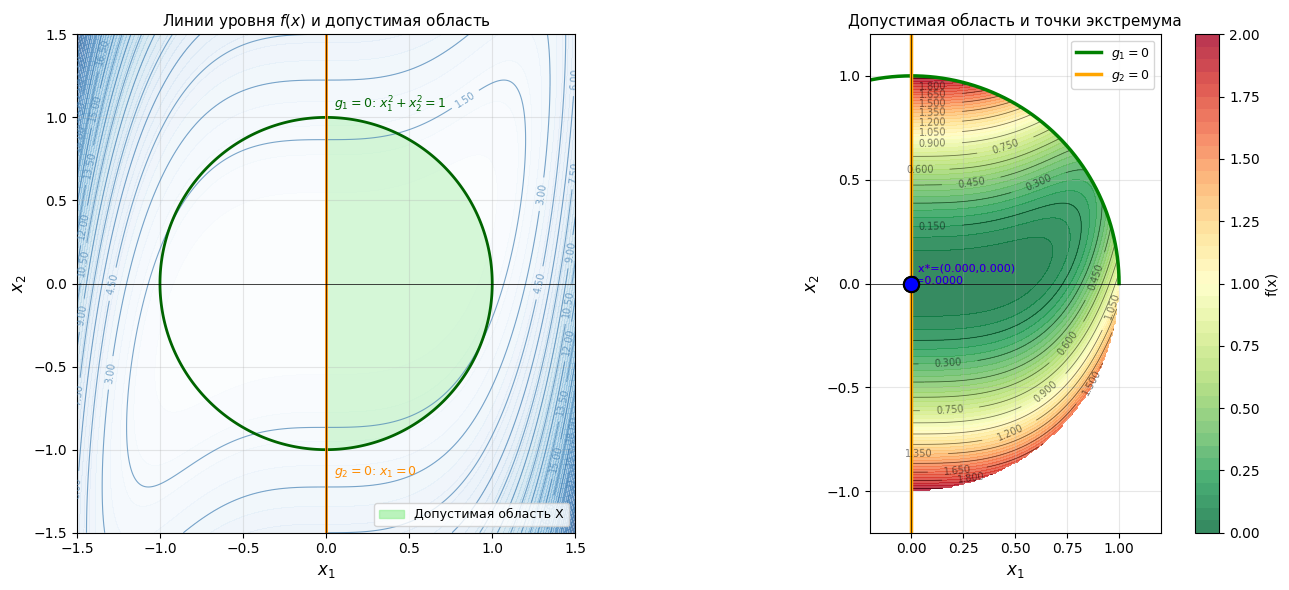

График сохранён: extremum_plot.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Сетка
N = 400
xx = np.linspace(-1.5, 1.5, N)
yy = np.linspace(-1.5, 1.5, N)
X1, X2 = np.meshgrid(xx, yy)
F  = (X1**3 - X2)**2 + X2**2
G1 = X1**2 + X2**2 - 1
G2 = -X1

# Допустимая область: G1<=0 AND G2<=0
feasible_mask = (G1 <= 0) & (G2 <= 0)

# ── Левый график: контурная карта + допустимая область ─────────────
ax = axes[0]
F_plot = np.where(feasible_mask, F, np.nan)
F_all  = F.copy()

# Фон — значения целевой функции по всей области
contf = ax.contourf(X1, X2, F_all, levels=50, cmap='Blues', alpha=0.4)

# Контуры уровней
levels_lines = np.linspace(0, F[feasible_mask].max()*1.1, 20) if feasible_mask.any() else 20
cs = ax.contour(X1, X2, F, levels=20, colors='steelblue', linewidths=0.8, alpha=0.7)
ax.clabel(cs, inline=True, fontsize=7, fmt='%.2f')

# Допустимая область (закрашенная)
ax.contourf(X1, X2, feasible_mask.astype(float), levels=[0.5, 1.5],
            colors=['lightgreen'], alpha=0.35)
ax.contour(X1, X2, G1, levels=[0], colors='darkgreen', linewidths=2)
ax.contour(X1, X2, G2, levels=[0], colors='darkorange', linewidths=2)

# Подписи ограничений
ax.text(0.05, 1.05, r'$g_1=0$: $x_1^2+x_2^2=1$', color='darkgreen', fontsize=9)
ax.text(0.05, -1.15, r'$g_2=0$: $x_1=0$', color='darkorange', fontsize=9)

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel(r'$x_1$', fontsize=12)
ax.set_ylabel(r'$x_2$', fontsize=12)
ax.set_title('Линии уровня $f(x)$ и допустимая область', fontsize=11)
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.grid(True, alpha=0.3)

green_patch = mpatches.Patch(color='lightgreen', alpha=0.6, label='Допустимая область X')
ax.legend(handles=[green_patch], loc='lower right', fontsize=9)

# ── Правый график: zoom на допустимую область с точками ────────────
ax2 = axes[1]

# Контуры целевой функции в допустимой области
F_feas = np.where(feasible_mask, F, np.nan)
contf2 = ax2.contourf(X1, X2, F_feas, levels=40, cmap='RdYlGn_r', alpha=0.8)
plt.colorbar(contf2, ax=ax2, label='f(x)')
cs2 = ax2.contour(X1, X2, F_feas, levels=15, colors='black', linewidths=0.6, alpha=0.5)
ax2.clabel(cs2, inline=True, fontsize=7, fmt='%.3f')

# Граница допустимой области
theta = np.linspace(0, np.pi/2, 200)
ax2.plot(np.cos(theta), np.sin(theta), 'g-', lw=2.5, label=r'$g_1=0$')
ax2.plot(np.cos(theta+np.pi/2), np.sin(theta+np.pi/2), 'g-', lw=2.5)
ax2.axvline(0, color='orange', lw=2.5, label=r'$g_2=0$')

# Наносим кандидатов
colors_pt = ['red','blue','purple','brown','magenta']
for i, c in enumerate(candidates):
    xv, fv, l1v, l2v, case = c
    x1v, x2v = float(xv[0]), float(xv[1])
    ax2.scatter(x1v, x2v, color=colors_pt[i%len(colors_pt)], s=120, zorder=5,
                edgecolors='k', linewidth=1.5)
    ax2.annotate(f'  x*=({x1v:.3f},{x2v:.3f})\nf={fv:.4f}',
                 (x1v, x2v), fontsize=8, color=colors_pt[i%len(colors_pt)])

ax2.set_xlim(-0.2, 1.2)
ax2.set_ylim(-1.2, 1.2)
ax2.set_xlabel(r'$x_1$', fontsize=12)
ax2.set_ylabel(r'$x_2$', fontsize=12)
ax2.set_title('Допустимая область и точки экстремума', fontsize=11)
ax2.set_aspect('equal')
ax2.axhline(0, color='k', lw=0.5)
ax2.axvline(0, color='k', lw=0.5)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('extremum_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: extremum_plot.png")


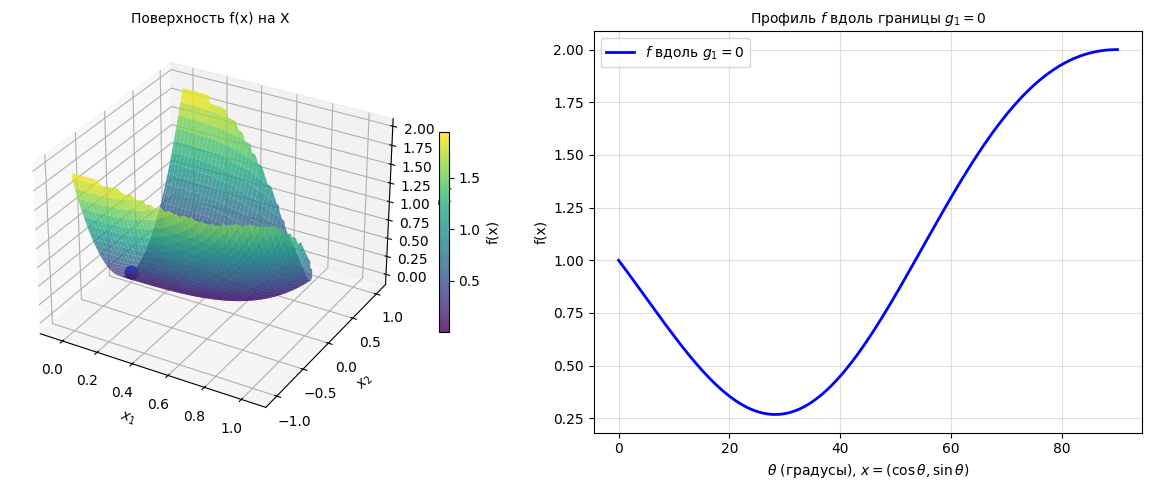

График сохранён: surface_plot.png


In [18]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 5))

# 3D поверхность
ax3d = fig.add_subplot(121, projection='3d')
N2 = 100
xx2 = np.linspace(-0.05, 1.05, N2)
yy2 = np.linspace(-1.05, 1.05, N2)
X1_2, X2_2 = np.meshgrid(xx2, yy2)
F2 = (X1_2**3 - X2_2)**2 + X2_2**2
G1_2 = X1_2**2 + X2_2**2 - 1
G2_2 = -X1_2
mask2 = (G1_2 <= 0) & (G2_2 <= 0)
F2_m = np.where(mask2, F2, np.nan)

surf = ax3d.plot_surface(X1_2, X2_2, F2_m, cmap='viridis', alpha=0.8, linewidth=0)
ax3d.set_xlabel(r'$x_1$')
ax3d.set_ylabel(r'$x_2$')
ax3d.set_zlabel(r'$f(x)$')
ax3d.set_title('Поверхность f(x) на X', fontsize=10)

# Точки экстремума на 3D
for i, c in enumerate(candidates):
    xv, fv = c[0], c[1]
    ax3d.scatter(float(xv[0]), float(xv[1]), fv,
                 color=colors_pt[i%len(colors_pt)], s=80, zorder=10, depthshade=False)

plt.colorbar(surf, ax=ax3d, shrink=0.5, label='f(x)')

# 2D профиль вдоль границы g1=0
ax2d = fig.add_subplot(122)
theta_range = np.linspace(0, np.pi/2, 500)
x1_bdry = np.cos(theta_range)
x2_bdry = np.sin(theta_range)
f_bdry  = (x1_bdry**3 - x2_bdry)**2 + x2_bdry**2
ax2d.plot(theta_range * 180/np.pi, f_bdry, 'b-', lw=2, label=r'$f$ вдоль $g_1=0$')
ax2d.set_xlabel(r'$\theta$ (градусы), $x=(\cos\theta, \sin\theta)$')
ax2d.set_ylabel('f(x)')
ax2d.set_title(r'Профиль $f$ вдоль границы $g_1=0$', fontsize=10)
ax2d.grid(True, alpha=0.4)
ax2d.legend()

# Отмечаем минимум/максимум на профиле
for i, c in enumerate(candidates):
    xv, fv = c[0], c[1]
    x1v, x2v = float(xv[0]), float(xv[1])
    if abs(x1v**2+x2v**2-1) < 1e-4 and x1v >= -1e-6:
        th = np.arctan2(x2v, x1v) * 180/np.pi
        ax2d.axvline(th, color=colors_pt[i%len(colors_pt)], linestyle='--', alpha=0.7)
        ax2d.scatter(th, fv, color=colors_pt[i%len(colors_pt)], s=80, zorder=5)
        ax2d.annotate(f'f={fv:.4f}', (th, fv), textcoords='offset points',
                      xytext=(5,5), fontsize=8, color=colors_pt[i%len(colors_pt)])

plt.tight_layout()
plt.savefig('surface_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("График сохранён: surface_plot.png")


## 8. Итоговые выводы

In [19]:
print("╔══════════════════════════════════════════════════════════════╗")
print("║              ИТОГОВЫЕ РЕЗУЛЬТАТЫ — Вариант 1.2              ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  Задача: f(x) = (x1³-x2)² + x2² → extr                    ║")
print(f"║  Ограничения: x1²+x2²≤1,  x1≥0                            ║")
print("╠══════════════════════════════════════════════════════════════╣")

if candidates:
    f_vals = [(c[1], c) for c in candidates]
    f_min_val = min(f_vals, key=lambda x: x[0])
    f_max_val = max(f_vals, key=lambda x: x[0])
    
    print(f"║  Найдено условно-стационарных точек: {len(candidates):<26}║")
    print("╠══════════════════════════════════════════════════════════════╣")
    for c in candidates:
        xv, fv, l1v, l2v, case = c
        print(f"║  x* = ({float(xv[0]):.4f}, {float(xv[1]):.4f}),  f* = {fv:.6f}  [{case}]")
    print("╠══════════════════════════════════════════════════════════════╣")
    print(f"║  min f = {f_min_val[0]:.6f}  в точке x={f_min_val[1][0]}")
    print(f"║  max f = {f_max_val[0]:.6f}  в точке x={f_max_val[1][0]}")
else:
    print("║  Кандидатов на экстремум не найдено                         ║")
print("╚══════════════════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════════════════╗
║              ИТОГОВЫЕ РЕЗУЛЬТАТЫ — Вариант 1.2              ║
╠══════════════════════════════════════════════════════════════╣
║  Задача: f(x) = (x1³-x2)² + x2² → extr                    ║
║  Ограничения: x1²+x2²≤1,  x1≥0                            ║
╠══════════════════════════════════════════════════════════════╣
║  Найдено условно-стационарных точек: 2                         ║
╠══════════════════════════════════════════════════════════════╣
║  x* = (0.0000, 0.0000),  f* = 0.000000  [случай 1]
║  x* = (0.0000, 0.0000),  f* = 0.000000  [случай 3]
╠══════════════════════════════════════════════════════════════╣
║  min f = 0.000000  в точке x=(0.0, 0.0)
║  max f = 0.000000  в точке x=(0.0, 0.0)
╚══════════════════════════════════════════════════════════════╝
